# Pubmat Checker — Testing Notebook

Notebook for testing checker.py

| Function | Runs for | Level |
|---|---| --- |
| logo_report() | All | error |
| check_logo_order() | All | error |
| check_pubmat_quality() | All | warning |
| check_watermark() |news, opportunities, holiday, other | error |
| check_readability() | All except photo | error |
| check_sgd() | Advisory, resolution | error |
| check_photo_quality() | photo | warning |
| check_template() | news, opportunities, photo, quote | error |
| generate_report() | Full pipeline | --- |
  
*Error: if check fails, overall result fails 
*Warning: if check fails, overall result pass (with issues)

## Imports and Setup

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import types
import torch
import pprint
pp = pprint.PrettyPrinter(indent=2)

from ultralytics import YOLO

from checker import (
    _run_doctr,
    _extract_ocr_data,
    check_watermark,
    check_readability,
    check_pubmat_quality,
    check_sgd,
    check_photo_quality,
    check_logo_order,
    logo_report,
    generate_report,
    _get_logo_boxes_abs,
    _mask_regions,
    load_spell_checker,
    check_spelling_on_image,
    SPELL_WORD_LISTS
)


## Load Test Image and YOLO

Image loaded: 1080x1350 px — uint8

0: 800x640 1 NYC_Correct, 1 BP_Correct, 1 SK_Correct, 60.0ms
Speed: 22.9ms preprocess, 60.0ms inference, 19.9ms postprocess per image at shape (1, 3, 800, 640)


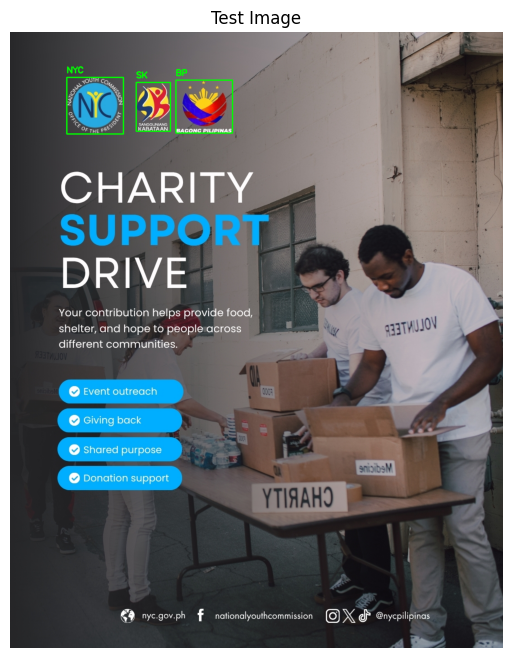

{ 'details': { 'logos': [ { 'confidence': 0.975,
                            'detected': True,
                            'level': 'error',
                            'logo': 'NYC',
                            'pass': True,
                            'remark': 'OK',
                            'status': 'Correct'},
                          { 'confidence': 0.949,
                            'detected': True,
                            'level': 'error',
                            'logo': 'BP',
                            'pass': True,
                            'remark': 'OK',
                            'status': 'Correct'},
                          { 'confidence': 0.938,
                            'detected': True,
                            'level': 'error',
                            'logo': 'SK',
                            'pass': True,
                            'remark': 'OK',
                            'status': 'Correct'}]},
  'label': 'All logos OK',
  'level': 'e

In [5]:
IMAGE_PATH = "test_set/images/test_7.jpg"
MODEL_PATH = r"C:\Users\user\Documents\DARLYN\SMARTech\pubmat-checker\training\runs\detect\tuned_model_v2\weights\best.pt"

image = cv2.imread(IMAGE_PATH)
assert image is not None, f"Failed to load image: {IMAGE_PATH}"

h, w = image.shape[:2]
print(f"Image loaded: {w}x{h} px — {image.dtype}")


logo_model = YOLO(MODEL_PATH)
logo_result, detected, annotated_img = logo_report(image, model=logo_model, conf_threshold= 0.8, collaborators=['sk'])

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis("off")
plt.show()
pp.pprint(logo_result)


## Run OCR

In [6]:

logo_boxes_abs = _get_logo_boxes_abs(detected, image.shape)
masked_image   = _mask_regions(image, logo_boxes_abs)

doctr_result = _run_doctr(masked_image)
ocr_words, ocr_confidences, ocr_boxes = _extract_ocr_data(doctr_result)
content_confidences = [c for c, b in zip(ocr_confidences, ocr_boxes) if b[1] < 0.90]  # ← should be 0.85
content_words       = [w for w, b in zip(ocr_words, ocr_boxes)  if b[1] < 0.90]       # ← should be 0.85
content_boxes       = [b for b in ocr_boxes if b[1] < 0.90]   

print(f'Words detected : {len(content_words)}')
print(f'Avg confidence : {round(sum(content_confidences)/len(content_confidences), 3) if content_confidences else 0}')
print(f'Sample words   : {content_words[:20]}')


  0%|          | 0/65814772 [00:00<?, ?it/s]

  0%|          | 0/63303144 [00:00<?, ?it/s]

Words detected : 27
Avg confidence : 0.928
Sample words   : ['CHARITY', 'SUPPOR', 'DRIVE', 'Your', 'contribution', 'helps', 'provide', 'food,', 'shelter,', 'and', 'hope', 'to', 'people', 'across', 'different', 'communities.', 'Event', 'outreach', '0001', 'Giving']


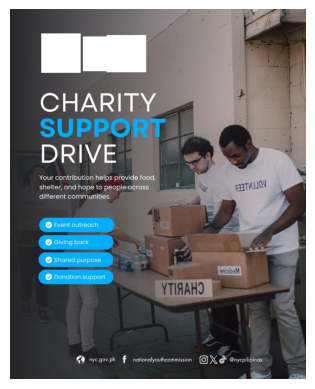

In [7]:
plt.imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [8]:
import pandas as pd
pd.DataFrame({
    "word": content_words,
    "conf": content_confidences
})

,word,conf
0,CHARITY,0.980344
1,SUPPOR,0.999099
2,DRIVE,0.898886
3,Your,0.986989
4,contribution,0.876451
5,helps,0.999297
6,provide,0.999541
7,"food,",0.997382
8,"shelter,",0.994038
9,and,0.993822


## Check Watermark
Pass the pre-computed bottom-15% OCR words so no second docTR call is made.

In [9]:
bottom_pairs = [(w, b) for w, b in zip(ocr_words, ocr_boxes) if b[1] >= 0.80]
wm_words = [p[0] for p in bottom_pairs]
wm_boxes = [p[1] for p in bottom_pairs]

print(f'Words in bottom 15%: {wm_words}')

wm_result, wm_boxes_abs = check_watermark(image, precomputed_words=wm_words, precomputed_boxes=wm_boxes)
pp.pprint(wm_result)


Words in bottom 15%: ['nyc.gov.ph', 'f', 'nationalyouthcommission', 'O', 'X', '@nycpilipinas']
{ 'details': {},
  'label': 'Watermark OK',
  'missing': [],
  'pass': True,
  'remark': 'OK'}


In [10]:
wm_fallback, _ = check_watermark(image)
pp.pprint(wm_fallback)

{ 'details': {},
  'label': 'Watermark OK',
  'missing': [],
  'pass': True,
  'remark': 'OK'}


## Check Readability


In [8]:
threshold = 0.6
readability = check_readability(content_confidences, threshold=threshold)
pp.pprint(readability)

{ 'details': {'average_confidence': 0.928, 'num_words': 27},
  'label': 'Readable',
  'pass': True,
  'remark': 'Average OCR confidence: 0.928'}


## Check Spelling

In [9]:
spell = load_spell_checker(SPELL_WORD_LISTS)

annotated, result = check_spelling_on_image(image, content_words, content_boxes, spell)

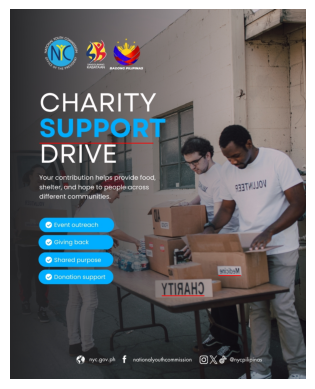

In [10]:
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [11]:
pp.pprint(result)

{ 'details': { 'errors': [ { 'box_abs': (108, 398, 522, 487),
                             'suggestions': ['supper', 'support'],
                             'word': 'SUPPOR'},
                           { 'box_abs': (761, 941, 841, 970),
                             'suggestions': [],
                             'word': 'enibibeM'},
                           { 'box_abs': (554, 996, 708, 1044),
                             'suggestions': [],
                             'word': 'YTIAAHO'}]},
  'label': '3 spelling error(s) found',
  'pass': False,
  'remark': 'SUPPOR, enibibeM, YTIAAHO'}


In [12]:
# Fallback: no pre-computed data — crops and re-runs docTR internally
wm_fallback = check_watermark(image)
print('Fallback result:')
pp.pprint(wm_fallback)

Fallback result:
( { 'details': {},
    'label': 'Watermark OK',
    'missing': [],
    'pass': True,
    'remark': 'OK'},
  [ (288, 1268, 386, 1292),
    (409, 1262, 426, 1294),
    (449, 1269, 663, 1291),
    (775, 1273, 781, 1280),
    (801, 1269, 920, 1292)])


## Check pubmat quality
Runs for all post types. Checks resolution ≥ 720×720, blur variance ≥ 50, contrast std ≥ 30.

In [13]:
quality = check_pubmat_quality(image)
pp.pprint(quality)

{ 'details': { 'Blur Metric': np.float64(667.0),
               'Contrast Metric': np.float64(47.7),
               'Resolution': '1080x1350'},
  'label': 'Pubmat quality OK',
  'pass': True,
  'remark': 'OK'}


## Check SGD
Applied to: advisory, resolution. Uses whole-word regex `\bsgd\b`, partial matches like "msgd" or "sgds" do not count.

In [14]:
# Unit tests
test_cases = [
    (['Pursuant', 'to', 'SGD', 'No.', '123'],  True),
    (['sgd', 'approved', 'by', 'the', 'board'], True),
    (['no', 'relevant', 'keyword', 'here'],      False),
    (['msgd', 'resolution', 'passed'],           False),  
    (['sgds', 'are', 'required'],                False),  
]

print('check_sgd() unit tests:')
all_ok = True
for words, expected in test_cases:
    result = check_sgd(words)
    ok = result['pass'] == expected
    if not ok: all_ok = False
    print(f'  {words}  → pass={result["pass"]} (expected {expected})')
print('All tests passed!' if all_ok else 'Some tests failed.')

check_sgd() unit tests:
  ['Pursuant', 'to', 'SGD', 'No.', '123']  → pass=True (expected True)
  ['sgd', 'approved', 'by', 'the', 'board']  → pass=True (expected True)
  ['no', 'relevant', 'keyword', 'here']  → pass=False (expected False)
  ['msgd', 'resolution', 'passed']  → pass=False (expected False)
  ['sgds', 'are', 'required']  → pass=False (expected False)
All tests passed!


In [15]:
# Run against actual OCR output from the loaded image, should fail if test not advisory bc no SGD
sgd_result = check_sgd(ocr_words)
pp.pprint(sgd_result)

{ 'details': {},
  'label': 'SGD MISSING',
  'pass': False,
  'remark': 'Use SGD for resolutions/advisories'}


## Check Photo Quality
Applied to: photo. Checks resolution ≥ 1080×1080, brightness ≥ 60, saturation ≥ 20.

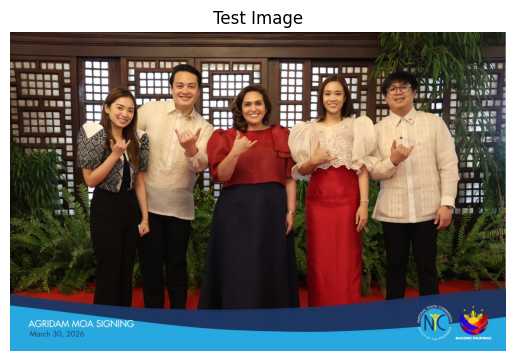

{ 'details': { 'brightness': 81.1,
               'mean_saturation': 112.2,
               'resolution': '2048x1317 (required at least 1080x1080)'},
  'label': 'Photo quality OK',
  'pass': True,
  'remark': 'OK'}


In [16]:
image = cv2.imread("test_set/images/test_2.jpg")
photo_result = check_photo_quality(image)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis("off")
plt.show()
pp.pprint(photo_result)


## Logo Order Check
Runs for all post types. NYC must be leftmost, BP rightmost, SK/YORP between them if required.

In [17]:
def make_mock_box(x0, y0, x1, y1):
    box = types.SimpleNamespace()
    box.xyxy = torch.tensor([[x0, y0, x1, y1]], dtype=torch.float32)
    return box

# Correct order: NYC → SK → BP
mock_detected = {
    'nyc':  {'status': 'correct', 'conf': 0.92, 'box': make_mock_box(10,  10, 80,  80)},
    'bp':   {'status': 'correct', 'conf': 0.88, 'box': make_mock_box(900, 10, 980, 80)},
    'sk':   {'status': 'correct', 'conf': 0.80, 'box': make_mock_box(450, 10, 530, 80)},
    'yorp': None,
}
order_result = check_logo_order(mock_detected, collaborators=['sk'])
pp.pprint(order_result)
assert order_result['pass'], 'Expected NYC → SK → BP to pass'

{ 'details': { 'order': 'NYC → SK → BP',
               'positions': { 'bp': np.float64(940.0),
                              'nyc': np.float64(45.0),
                              'sk': np.float64(490.0)}},
  'label': 'Logo order OK',
  'pass': True,
  'remark': 'OK'}


In [18]:
# Wrong order: SK is to the left of NYC
mock_wrong_order = {
    'nyc':  {'status': 'correct', 'conf': 0.92, 'box': make_mock_box(200, 10, 280, 80)},
    'bp':   {'status': 'correct', 'conf': 0.88, 'box': make_mock_box(900, 10, 980, 80)},
    'sk':   {'status': 'correct', 'conf': 0.80, 'box': make_mock_box(10,  10, 90,  80)},
    'yorp': None,
}
wrong_order = check_logo_order(mock_wrong_order, collaborators=['sk'])
pp.pprint(wrong_order)

{ 'details': { 'order': 'SK → NYC → BP',
               'positions': { 'bp': np.float64(940.0),
                              'nyc': np.float64(240.0),
                              'sk': np.float64(50.0)}},
  'label': 'Logo order issues',
  'pass': False,
  'remark': 'NYC should be leftmost | SK should be to the right of NYC'}


In [19]:
# Missing BP 
mock_missing_bp = {
    'nyc':  {'status': 'correct', 'conf': 0.92, 'box': make_mock_box(10, 10, 80, 80)},
    'bp':   None,
    'sk':   None,
    'yorp': None,
}
missing_result = check_logo_order(mock_missing_bp, collaborators=(""))
pp.pprint(missing_result)


{ 'details': {},
  'label': 'Cannot check logo order',
  'pass': False,
  'remark': 'Missing NYC or BP logo prevents order validation'}


## Full Report 


In [16]:
def print_audit(audit):
    print("=" * 60)
    print(f"OVERALL RESULT: {audit.get('overall', 'N/A')}")
    print(f"POST TYPE: {audit.get('post_type', 'N/A')}")
    print("=" * 60)

    #  LOGOS 
    logos = audit.get('logos', {})
    print("\n[LOGOS]")
    print(f"Status: {logos.get('label')} | Pass: {logos.get('pass')}")
    
    for l in logos.get('details', {}).get('logos', []):
        print(f"  - {l['logo']}: {l['status']} "
              f"(Conf: {l['confidence']}) | Pass: {l['pass']}")

    #  LOGO ORDER 
    order = audit.get('logo_order', {})
    print("\n[LOGO ORDER]")
    print(f"Status: {order.get('label')} | Pass: {order.get('pass')}")
    details = order.get('details', {})
    print(f"  Order: {details.get('order')}")
    print(f"  Positions: {details.get('positions')}")

    #  QUALITY 
    quality = audit.get('pubmat_quality', {})
    print("\n[PUBMAT QUALITY]")
    print(f"Status: {quality.get('label')} | Pass: {quality.get('pass')}")
    for k, v in quality.get('details', {}).items():
        print(f"  {k}: {v}")

    #  READABILITY 
    readability = audit.get('readability', {})
    print("\n[READABILITY]")
    print(f"Status: {readability.get('label')} | Pass: {readability.get('pass')}")
    print(f"  {readability.get('remark')}")

    # SPELLING 
    spelling = audit.get('spelling', {})
    print("\n[SPELLING]")
    print(f"Status: {spelling.get('label')} | Pass: {spelling.get('pass')}")
    
    errors = spelling.get('details', {}).get('errors', [])
    if errors:
        for e in errors:
            print(f"  - Word: {e['word']}")
            print(f"    Suggestions: {e['suggestions']}")
            print(f"    Box: {e['box_abs']}")
    else:
        print("  No spelling errors")

    #  WATERMARK 
    watermark = audit.get('watermark', {})
    print("\n[WATERMARK]")
    print(f"Status: {watermark.get('label')} | Pass: {watermark.get('pass')}")
    if watermark.get('missing'):
        print(f"  Missing: {watermark['missing']}")

    print("=" * 60)

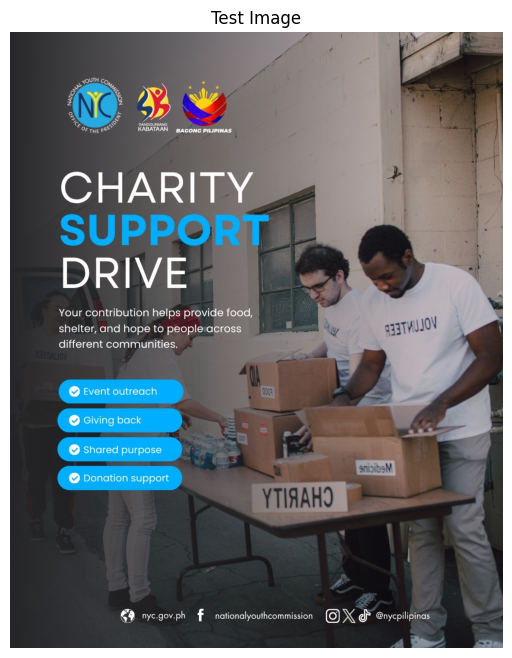

In [11]:
IMAGE_PATH ='test_set/images/test_7.jpg'
image = cv2.imread(IMAGE_PATH)  #  test image

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis("off")
plt.show()

In [17]:
model = YOLO("best.pt")    # change model path to the latest
full_report, annotated = generate_report(
    image,
    model,
    post_type='other',  # change to test other post types
    collaborators=['sk']  # add 'sk' or 'yorp' if needed
)

# print raw report
pp.pprint(full_report) # test_7 should pass, test_36 should pass (with issue: photo qual check)


0: 800x640 1 NYC_Correct, 1 BP_Correct, 1 SK_Correct, 16.0ms
Speed: 4.0ms preprocess, 16.0ms inference, 1.1ms postprocess per image at shape (1, 3, 800, 640)
{ 'logo_order': { 'details': { 'order': 'NYC → SK → BP',
                               'positions': { 'bp': np.float64(425.0),
                                              'nyc': np.float64(185.5),
                                              'sk': np.float64(313.0)}},
                  'label': 'Logo order OK',
                  'pass': True,
                  'remark': 'OK'},
  'logos': { 'details': { 'logos': [ { 'confidence': 0.973,
                                       'detected': True,
                                       'level': 'error',
                                       'logo': 'NYC',
                                       'pass': True,
                                       'remark': 'OK',
                                       'status': 'Correct'},
                                     { 'confidence': 0.961,


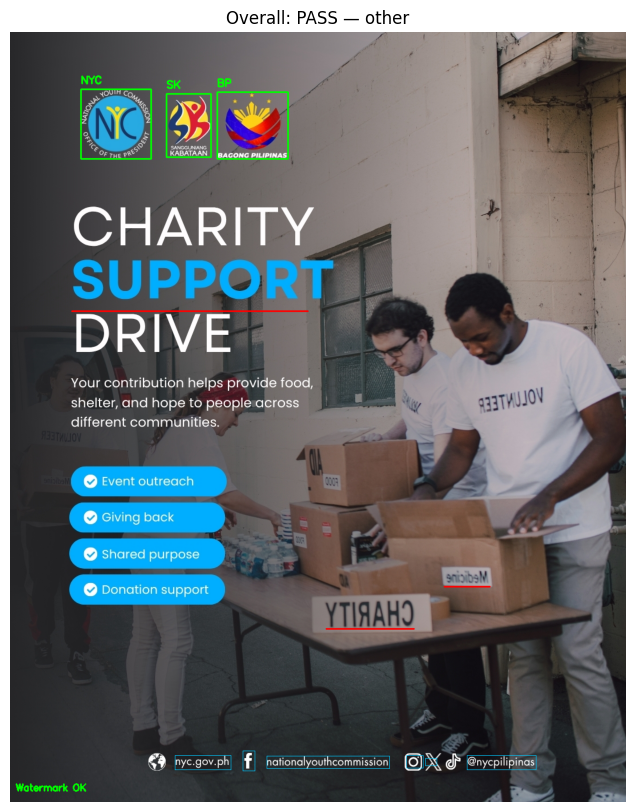

In [18]:
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Overall: {full_report['overall']} — {full_report['post_type']}")
plt.axis('off')
plt.show()

In [19]:
print_audit(full_report)

OVERALL RESULT: PASS
POST TYPE: other

[LOGOS]
Status: All logos OK | Pass: True
  - NYC: Correct (Conf: 0.973) | Pass: True
  - BP: Correct (Conf: 0.961) | Pass: True
  - SK: Correct (Conf: 0.95) | Pass: True

[LOGO ORDER]
Status: Logo order OK | Pass: True
  Order: NYC → SK → BP
  Positions: {'nyc': np.float64(185.5), 'bp': np.float64(425.0), 'sk': np.float64(313.0)}

[PUBMAT QUALITY]
Status: Pubmat quality OK | Pass: True
  Resolution: 1080x1350
  Blur Metric: 667.0
  Contrast Metric: 47.7

[READABILITY]
Status: Readable | Pass: True
  Average OCR confidence: 0.928

[SPELLING]
Status: 3 spelling error(s) found | Pass: False
  - Word: SUPPOR
    Suggestions: ['supper', 'support']
    Box: (108, 398, 522, 487)
  - Word: enibibeM
    Suggestions: []
    Box: (761, 941, 841, 970)
  - Word: YTIAAHO
    Suggestions: []
    Box: (554, 996, 708, 1044)

[WATERMARK]
Status: Watermark OK | Pass: True
